# Badanie cen mieszkań w Polsce w 2025 za pomocą regresji wielorakiej

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.model_selection import train_test_split

### Wczytanie bazy

In [3]:
data= pd.read_csv("Baza do regrasji.csv",sep=";",encoding='windows-1250')
print(data.shape)
data


(81, 5)


,Cena mieszkania,Powierzchnia,Miasto,Pokoje,Rok budowy
0,436 000,34.43,Poznan,1,2010
1,540 320,49.12,Poznan,2,1999
2,470 000,42,Poznan,2,1974
3,340 000,27.50,Poznan,1,1961
4,450 000,31.6,Poznan,2,2020
...,...,...,...,...,...
76,949000,72.2,Warszawa,3,1990
77,1750000,114.57,Warszawa,4,1997
78,890000,53.4,Warszawa,3,1972
79,649000,47,Warszawa,3,1960


In [4]:
data["Cena mieszkania"]=data["Cena mieszkania"].str.replace(" ","")
data["Powierzchnia"]=data["Powierzchnia"].str.replace(" ","")
data["Miasto"]=data["Miasto"].str.replace(" ","")
data["Pokoje"]=data["Pokoje"].replace(" ","")
data["Rok budowy"]=data["Rok budowy"].replace(" ","")

data["Cena mieszkania"]=data["Cena mieszkania"].astype(float)
data["Powierzchnia"]=data["Powierzchnia"].astype(float)
data["Pokoje"]=data["Pokoje"].astype(float)
data["Rok budowy"]=data["Rok budowy"].astype(float)

data.head()

,Cena mieszkania,Powierzchnia,Miasto,Pokoje,Rok budowy
0,436000.0,34.43,Poznan,1.0,2010.0
1,540320.0,49.12,Poznan,2.0,1999.0
2,470000.0,42.00,Poznan,2.0,1974.0
3,340000.0,27.50,Poznan,1.0,1961.0
4,450000.0,31.60,Poznan,2.0,2020.0


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 81 entries, 0 to 80
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Cena mieszkania  81 non-null     float64
 1   Powierzchnia     81 non-null     float64
 2   Miasto           81 non-null     object 
 3   Pokoje           81 non-null     float64
 4   Rok budowy       81 non-null     float64
dtypes: float64(4), object(1)
memory usage: 3.3+ KB


### Usunięcie outlierów - detekcja i eliminacja obserwacji odstających

In [6]:
sr_cena=data["Cena mieszkania"].mean()
odch_std_ceny = data["Cena mieszkania"].std()

z_score_ceny = (data["Cena mieszkania"] - sr_cena) / odch_std_ceny
filter = abs(z_score_ceny) < 3
data = data[filter]

data.reset_index(drop=True, inplace=True)

print(data.shape)

(78, 5)


### Macierz korelacji oraz wpływ miasta na cenę

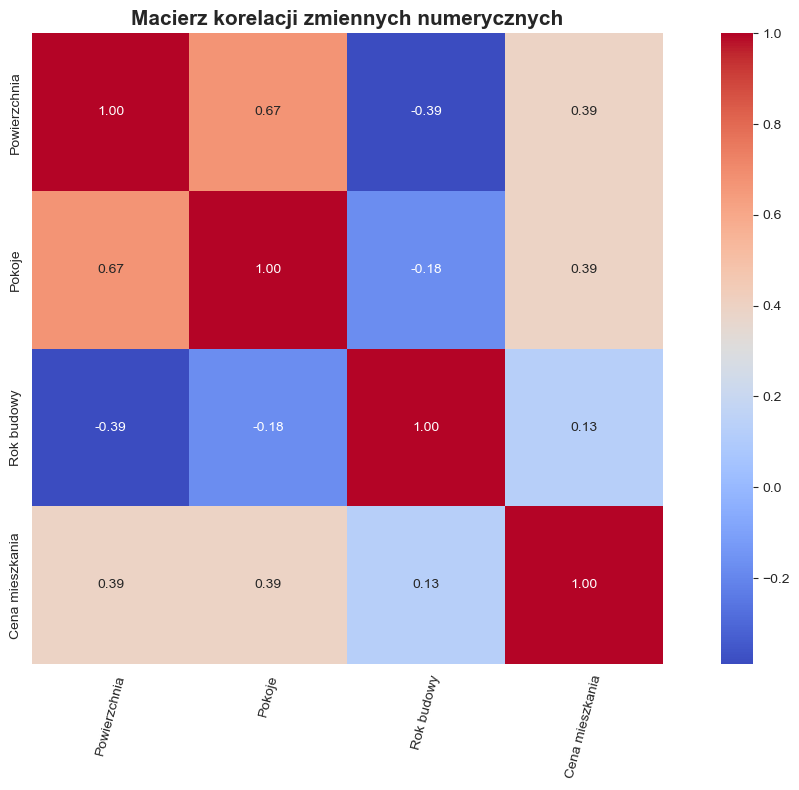

In [7]:
import seaborn as sns

data_num = data[['Powierzchnia','Pokoje','Rok budowy','Cena mieszkania']]
corr_matrix = data_num.corr()

plt.figure(figsize=(12,8))
sns.heatmap(corr_matrix,
            annot=True,
            fmt=".2f",
            cmap="coolwarm",
            square=True)
plt.xticks(rotation=75)
plt.title("Macierz korelacji zmiennych numerycznych", fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

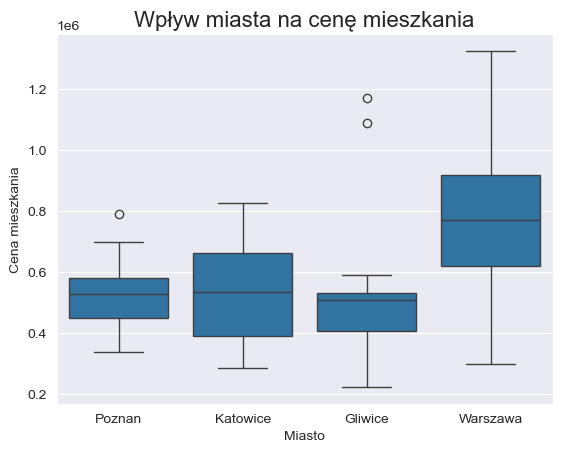

In [8]:
sns.boxplot(x='Miasto', y='Cena mieszkania', data=data)
plt.title("Wpływ miasta na cenę mieszkania", fontsize=16)
plt.show()

### Przygotowanie danych dla modelu

In [9]:
X = data[['Miasto','Powierzchnia','Pokoje','Rok budowy']]
y = data["Cena mieszkania"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=True)

In [10]:
ohe = OneHotEncoder(drop='first', sparse_output=False)
X_train_cat = ohe.fit_transform(X_train[['Miasto']])
X_test_cat  = ohe.transform(X_test[['Miasto']])
cat_cols = ohe.get_feature_names_out()


In [11]:
X_train_num = X_train[['Powierzchnia','Pokoje','Rok budowy']]
X_test_num  = X_test[['Powierzchnia','Pokoje','Rok budowy']]

# Można wykorzystać skalowanie danych aby sprawdzić wpływ poszczególnych danych w regresji
scaler = StandardScaler()
X_train_num_scaled = pd.DataFrame(scaler.fit_transform(X_train_num), columns=X_train_num.columns)
X_test_num_scaled  = pd.DataFrame(scaler.transform(X_test_num), columns=X_test_num.columns)

X_train_cat= pd.DataFrame(X_train_cat, columns=cat_cols)
X_test_cat = pd.DataFrame(X_test_cat, columns=cat_cols)

X_train_scaled = pd.concat([X_train_cat, X_train_num_scaled], axis=1)
X_test_scaled  = pd.concat([X_test_cat, X_test_num_scaled], axis=1)

X_train_scaled.head()

,Miasto_Katowice,Miasto_Poznan,Miasto_Warszawa,Powierzchnia,Pokoje,Rok budowy
0,1.0,0.0,0.0,-0.276804,-0.752452,-0.095036
1,0.0,0.0,0.0,-0.264440,0.385402,1.019710
2,0.0,1.0,0.0,0.436776,0.385402,1.019710
3,0.0,1.0,0.0,0.718205,1.523256,-0.732034
4,1.0,0.0,0.0,0.194206,0.385402,-0.509084


### Model i jego walidacja

In [13]:
model = LinearRegression()
model.fit(X_train_scaled, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [14]:
y_pred_train = model.predict(X_train_scaled)
y_pred_test = model.predict(X_test_scaled)

r2_train = r2_score(y_train, y_pred_train)
r2_test  = r2_score(y_test, y_pred_test)

mse_train = mean_squared_error(y_train, y_pred_train)
mse_test = mean_squared_error(y_test, y_pred_test)

print("Intercept:", model.intercept_)
print("R^2 (train):", r2_train)
print("R^2 (test):", r2_test)
print("MSE (train):", mse_train)
print("MSE (test):", mse_test)

Intercept: 495309.26028394245
R^2 (train): 0.5709348537022988
R^2 (test): 0.590234475028311
MSE (train): 17774961088.777195
MSE (test): 23834285922.182243


In [15]:
#Współczynniki dla cech

coef_df = pd.DataFrame({
    'feature': list(X_train_scaled.columns),
    'coefficient': model.coef_
}).sort_values(by='coefficient', key=abs, ascending=False)

print(coef_df)

           feature    coefficient
2  Miasto_Warszawa  297480.669489
3     Powierzchnia  113846.898714
5       Rok budowy   69865.470711
1    Miasto_Poznan   58823.357107
4           Pokoje   18124.816946
0  Miasto_Katowice     847.320809


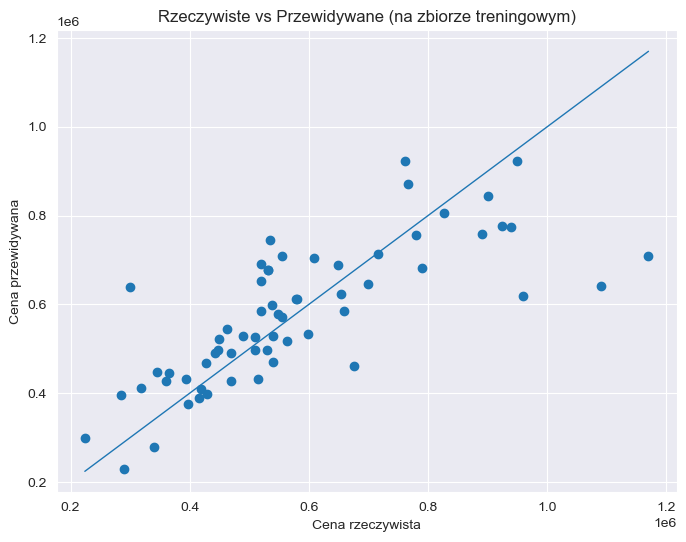

In [16]:
plt.figure(figsize=(8,6))
plt.scatter(y_train, y_pred_train)
plt.plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], linewidth=1)
plt.xlabel("Cena rzeczywista")
plt.ylabel("Cena przewidywana")
plt.title("Rzeczywiste vs Przewidywane (na zbiorze treningowym)")
plt.grid(True)
plt.show()

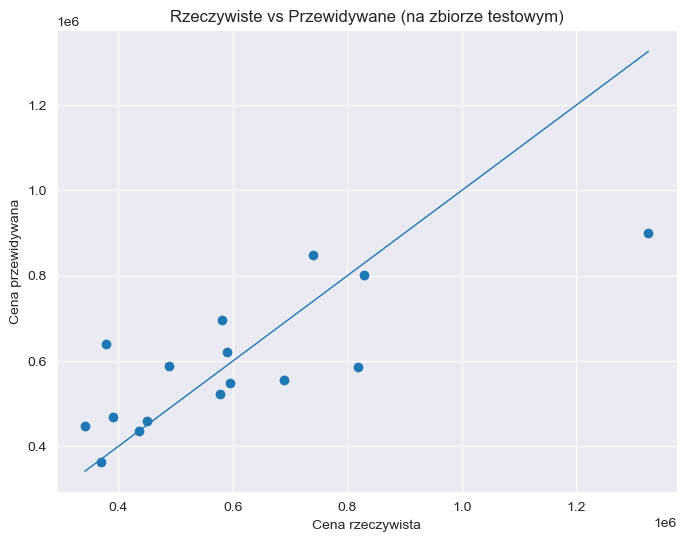

In [17]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred_test)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], linewidth=1)
plt.xlabel("Cena rzeczywista")
plt.ylabel("Cena przewidywana")
plt.title("Rzeczywiste vs Przewidywane (na zbiorze testowym)")
plt.grid(True)
plt.show()

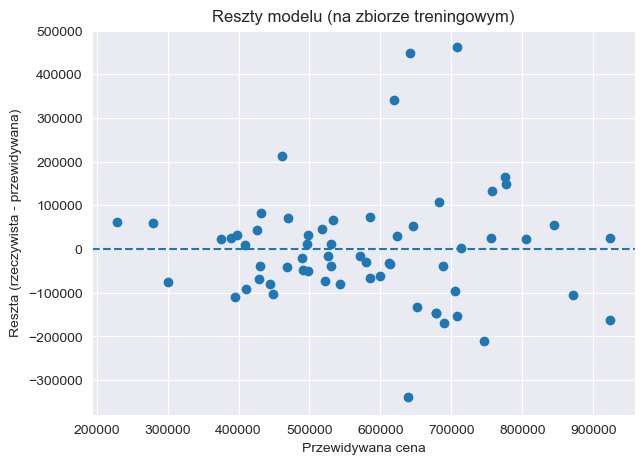

In [18]:
residuals = y_train - y_pred_train
plt.figure(figsize=(7,5))
plt.scatter(y_pred_train, residuals)
plt.axhline(0, linestyle='--')
plt.xlabel("Przewidywana cena")
plt.ylabel("Reszta (rzeczywista - przewidywana)")
plt.title("Reszty modelu (na zbiorze treningowym)")
plt.grid(True)
plt.show()

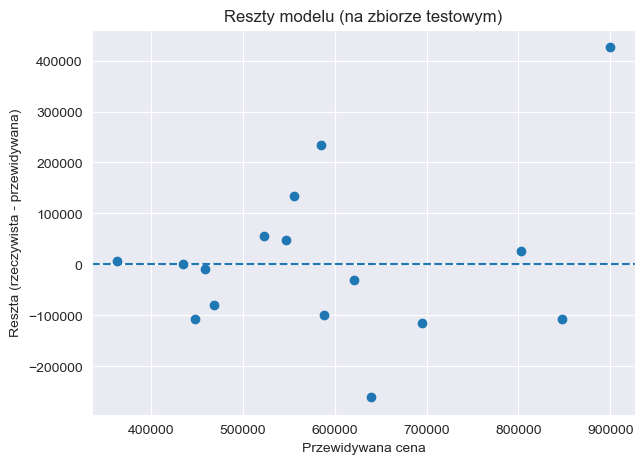

In [19]:
residuals = y_test - y_pred_test
plt.figure(figsize=(7,5))
plt.scatter(y_pred_test, residuals)
plt.axhline(0, linestyle='--')
plt.xlabel("Przewidywana cena")
plt.ylabel("Reszta (rzeczywista - przewidywana)")
plt.title("Reszty modelu (na zbiorze testowym)")
plt.grid(True)
plt.show()